# Loan Approval Prediction: Exploratory Data Analysis

This notebook explores the Kaggle Loan Prediction dataset and documents the evidence behind the project's preprocessing and modeling decisions. The analysis is intentionally limited to data understanding and visualization; no model training, preprocessing pipeline, or deployment code is included.

In [1]:
import sys
print(sys.executable)

c:\Users\kunal\OneDrive\Desktop\Coding\Project\mlintern\project 1 - loan approval predictor\.venv\Scripts\python.exe


## 1. Project Introduction

### Problem statement
Financial institutions must assess loan applications consistently while managing credit risk. Manual review can be time-consuming and may produce inconsistent decisions.

### Business objective
The business objective is to support faster and more consistent preliminary loan screening by identifying applicant profiles associated with loan approval. The system is an educational decision-support prototype, not a replacement for regulated credit underwriting.

### Machine learning objective
The machine learning objective is to predict `Loan_Status` (`Y` for approved and `N` for rejected) from applicant demographics, income, requested loan details, credit history, and property area.

### Dataset overview
The dataset contains applicant-level records with numerical and categorical variables. This EDA examines data quality, target distribution, feature behavior, relationships with the target, correlations, and outliers before modeling.

## 2. Load Dataset

The analysis uses the raw training file at `data/raw/train.csv`. The path fallback makes the notebook runnable from either the project root or the `notebooks` directory.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook", palette="Set2")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "figure.titlesize": 15,
})

DATA_PATH = Path("data/raw/train.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("../data/raw/train.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH.resolve()}")

data = pd.read_csv(DATA_PATH)
print(f"Dataset path: {DATA_PATH.resolve()}")
print(f"Shape: {data.shape[0]:,} rows x {data.shape[1]} columns")
display(data.head())
data.info()

Dataset path: C:\Users\kunal\OneDrive\Desktop\Coding\Project\mlintern\project 1 - loan approval predictor\data\raw\train.csv
Shape: 614 rows x 13 columns


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


The initial inspection confirms the number of observations, the available predictor types, and the presence of the target column. `Loan_ID` is an identifier rather than a meaningful applicant attribute and is therefore excluded from modeling in the project configuration.

## 3. Dataset Inspection

This section checks data types, missingness, duplicate records, and numerical summaries. These checks identify data quality risks before any model is trained.

In [3]:
print("Data types")
display(data.dtypes.rename("dtype").to_frame())

print("Missing values")
missing_summary = (
    data.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda frame: frame["missing_count"] / len(data) * 100)
    .sort_values("missing_count", ascending=False)
)
display(missing_summary)

print(f"Duplicate rows: {data.duplicated().sum()}")

print("Summary statistics")
display(data.describe(include="all").T)

Data types


,dtype
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


Missing values


,missing_count,missing_percent
Credit_History,50,8.143322
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599
Loan_ID,0,0.000000
Education,0,0.000000
ApplicantIncome,0,0.000000


Duplicate rows: 0
Summary statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP001002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,NaN,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.0,81000.0
CoapplicantIncome,614.0,NaN,NaN,NaN,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,NaN,NaN,NaN,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0
Loan_Amount_Term,600.0,NaN,NaN,NaN,342.0,65.12041,12.0,360.0,360.0,360.0,480.0


The missing-value table is especially important because several fields may be absent for individual applications. The project therefore handles numerical missing values with median imputation and categorical missing values with mode imputation inside the modeling pipeline, preventing information from leaking across the train-test boundary.

## 4. Target Variable Analysis

The target distribution shows how many applications were approved versus rejected. This determines whether accuracy alone is sufficient and motivates the use of precision, recall, F1 score, and ROC AUC during evaluation.

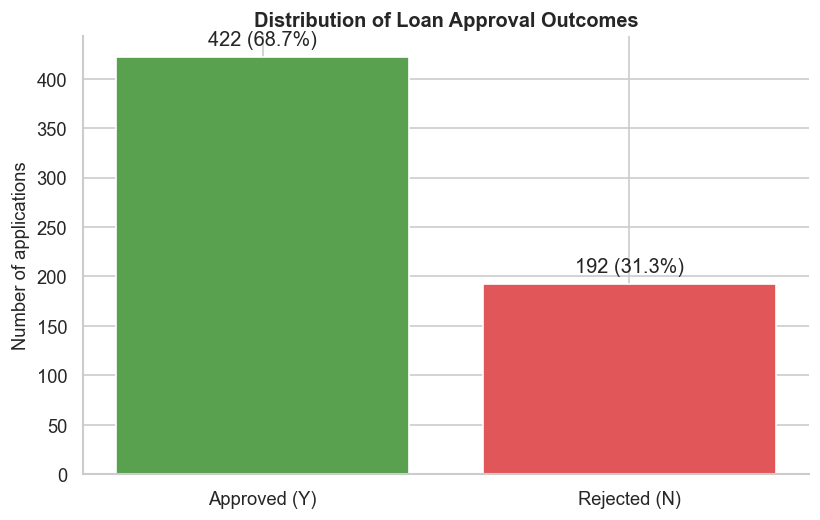

,count,percent
Loan_Status,,
Y,422,68.73
N,192,31.27


In [4]:
target_counts = data["Loan_Status"].value_counts().reindex(["Y", "N"])
target_percent = target_counts / target_counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(["Approved (Y)", "Rejected (N)"], target_counts.values, color=["#59a14f", "#e15759"])
ax.set_title("Distribution of Loan Approval Outcomes")
ax.set_ylabel("Number of applications")
for bar, count, percent in zip(bars, target_counts.values, target_percent.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            f"{count:,} ({percent:.1f}%)", ha="center", va="bottom")
sns.despine()
plt.tight_layout()
plt.show()

display(pd.DataFrame({"count": target_counts, "percent": target_percent.round(2)}))

The target is not perfectly balanced: approved applications are more common than rejected applications. A model can therefore achieve deceptively strong accuracy by favoring the majority class. F1 and ROC AUC provide a more informative view of performance, especially when rejected applications matter operationally.

## 5. Univariate Analysis

The following visualizations describe each predictor independently. Categorical plots show frequency, while numerical plots show distribution, skewness, and the potential need for robust imputation and scaling.

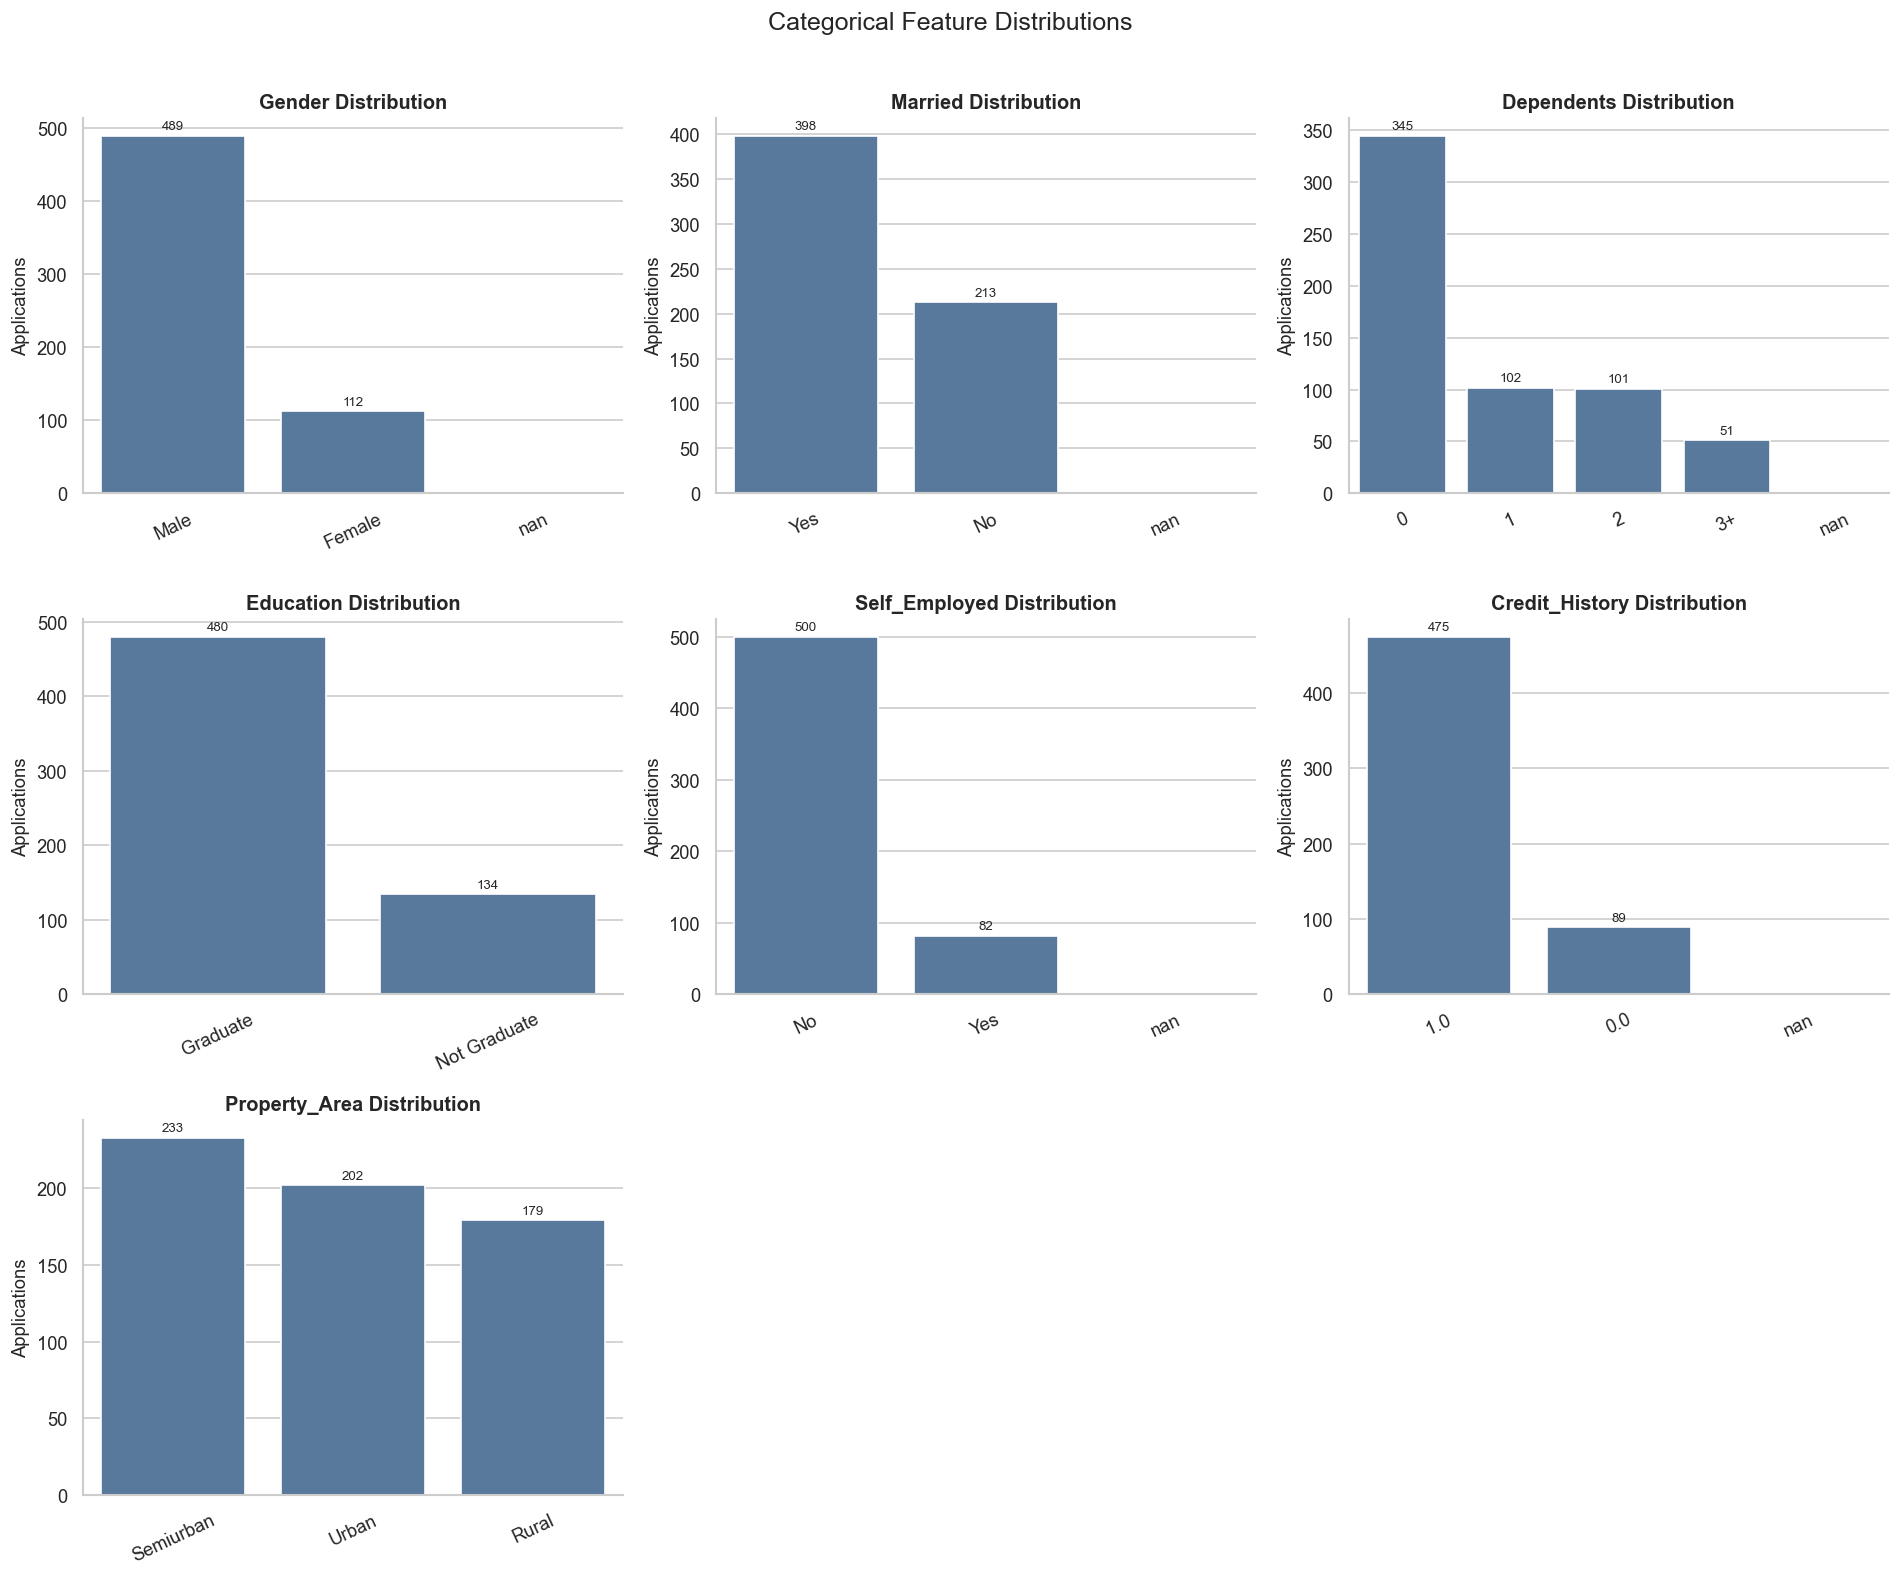

In [5]:
categorical_features = [
    "Gender", "Married", "Dependents", "Education",
    "Self_Employed", "Credit_History", "Property_Area",
]
numerical_features = [
    "ApplicantIncome", "CoapplicantIncome", "LoanAmount",
    "Loan_Amount_Term",
]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()
for ax, feature in zip(axes, categorical_features):
    order = data[feature].value_counts(dropna=False).index
    sns.countplot(data=data, x=feature, order=order, ax=ax, color="#4e79a7")
    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel("")
    ax.set_ylabel("Applications")
    ax.tick_params(axis="x", rotation=25)
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=2, fontsize=8)
for ax in axes[len(categorical_features):]:
    ax.remove()
fig.suptitle("Categorical Feature Distributions", y=1.01)
sns.despine()
plt.tight_layout()
plt.show()

Each count plot makes category frequency and rare levels visible. These distributions justify categorical imputation and one-hot encoding. `Credit_History` is a binary feature and is especially important to inspect because it can strongly separate approval outcomes.

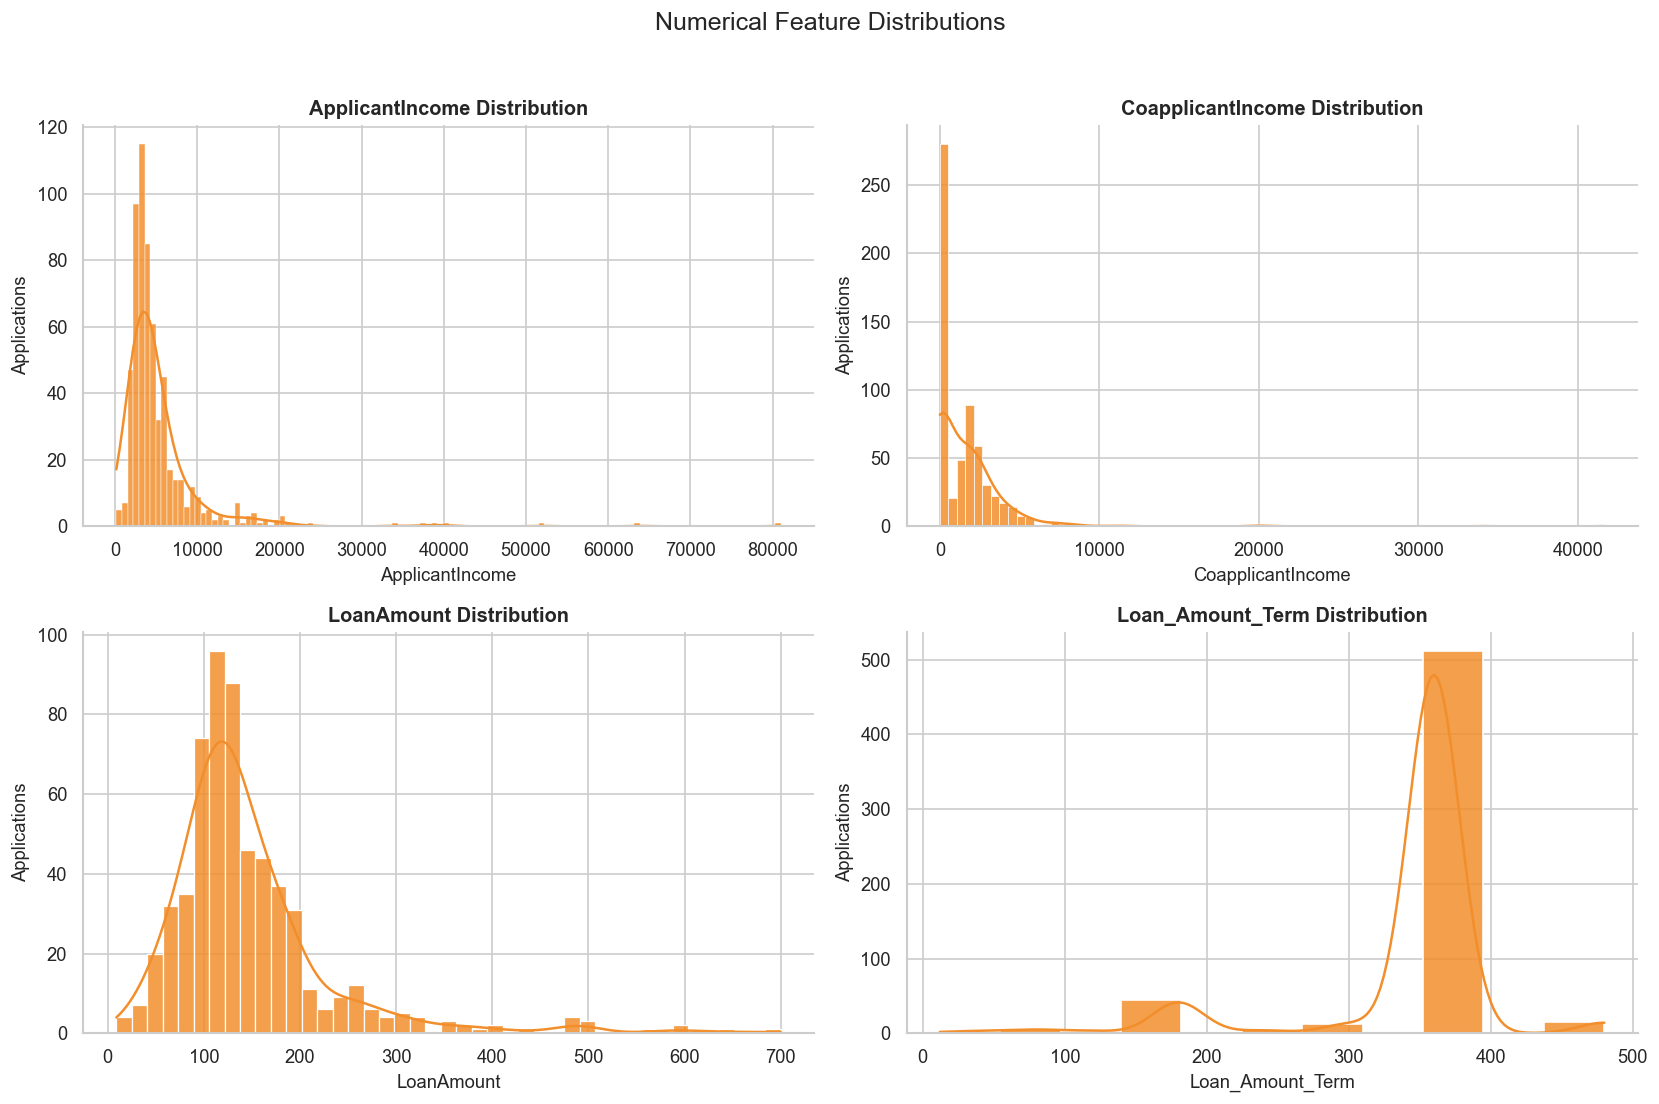

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, feature in zip(axes.flat, numerical_features):
    sns.histplot(data=data, x=feature, kde=True, ax=ax, color="#f28e2b",
                 edgecolor="white", alpha=0.85)
    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel(feature)
    ax.set_ylabel("Applications")
fig.suptitle("Numerical Feature Distributions", y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

The numerical distributions are typically right-skewed, particularly for income and loan amount. This means extreme values can influence linear models and distance-based scale comparisons. Standard scaling is therefore appropriate for numerical inputs, while tree-based models can provide a useful nonlinear comparison.

## 6. Bivariate Analysis

These plots compare each selected feature with `Loan_Status`. They are descriptive relationships, not causal conclusions.

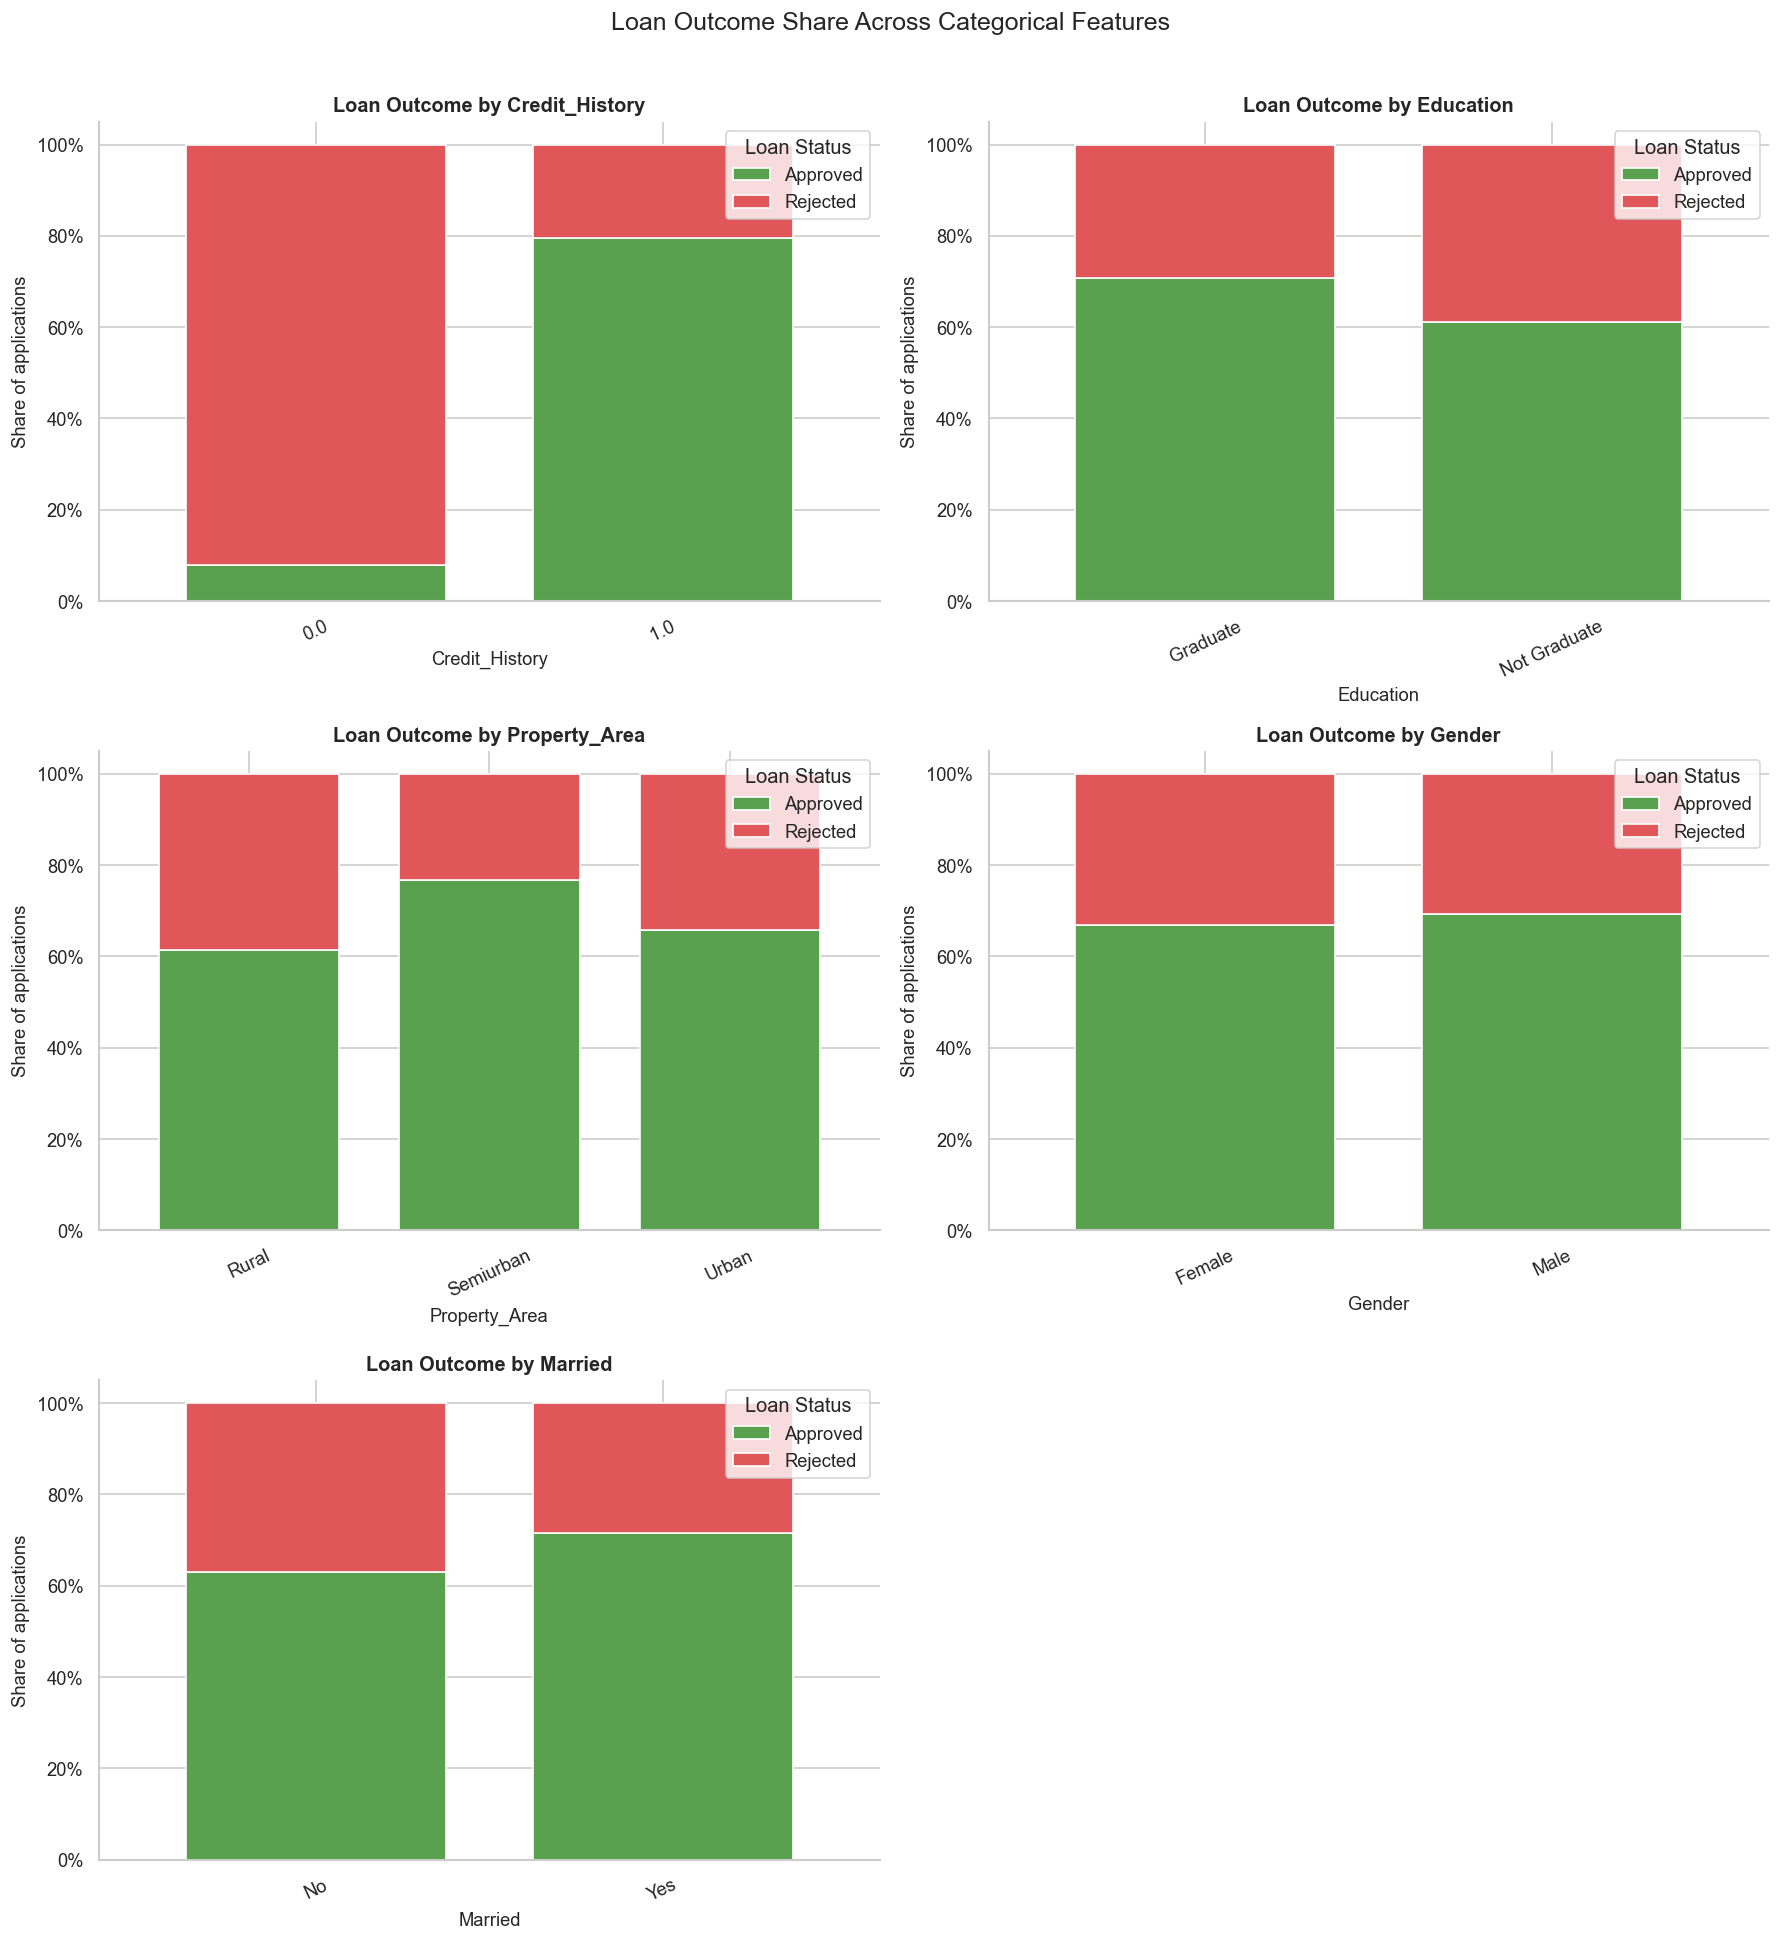

In [7]:
target_order = ["Y", "N"]
categorical_target_features = [
    "Credit_History", "Education", "Property_Area",
    "Gender", "Married",
]

fig, axes = plt.subplots(3, 2, figsize=(15, 16))
for ax, feature in zip(axes.flat, categorical_target_features):
    cross_tab = pd.crosstab(data[feature], data["Loan_Status"], normalize="index")
    cross_tab = cross_tab.reindex(columns=target_order, fill_value=0)
    cross_tab.plot(kind="bar", stacked=True, ax=ax, color=["#59a14f", "#e15759"],
                   width=0.75)
    ax.set_title(f"Loan Outcome by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Share of applications")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
    ax.legend(title="Loan Status", labels=["Approved", "Rejected"], loc="upper right")
    ax.tick_params(axis="x", rotation=25)
axes[-1, -1].axis("off")
fig.suptitle("Loan Outcome Share Across Categorical Features", y=1.01)
sns.despine()
plt.tight_layout()
plt.show()

The stacked proportions show how approval rates vary within categories rather than being driven only by category frequency. A substantial difference across `Credit_History` levels would support retaining it as a core predictor. Smaller differences for a feature suggest that it may contribute less predictive information on its own while still adding context in combination with other variables.

C:\Users\kunal\AppData\Local\Temp\ipykernel_15292\2622197907.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="Loan_Status", y=feature, order=target_order,
C:\Users\kunal\AppData\Local\Temp\ipykernel_15292\2622197907.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="Loan_Status", y=feature, order=target_order,


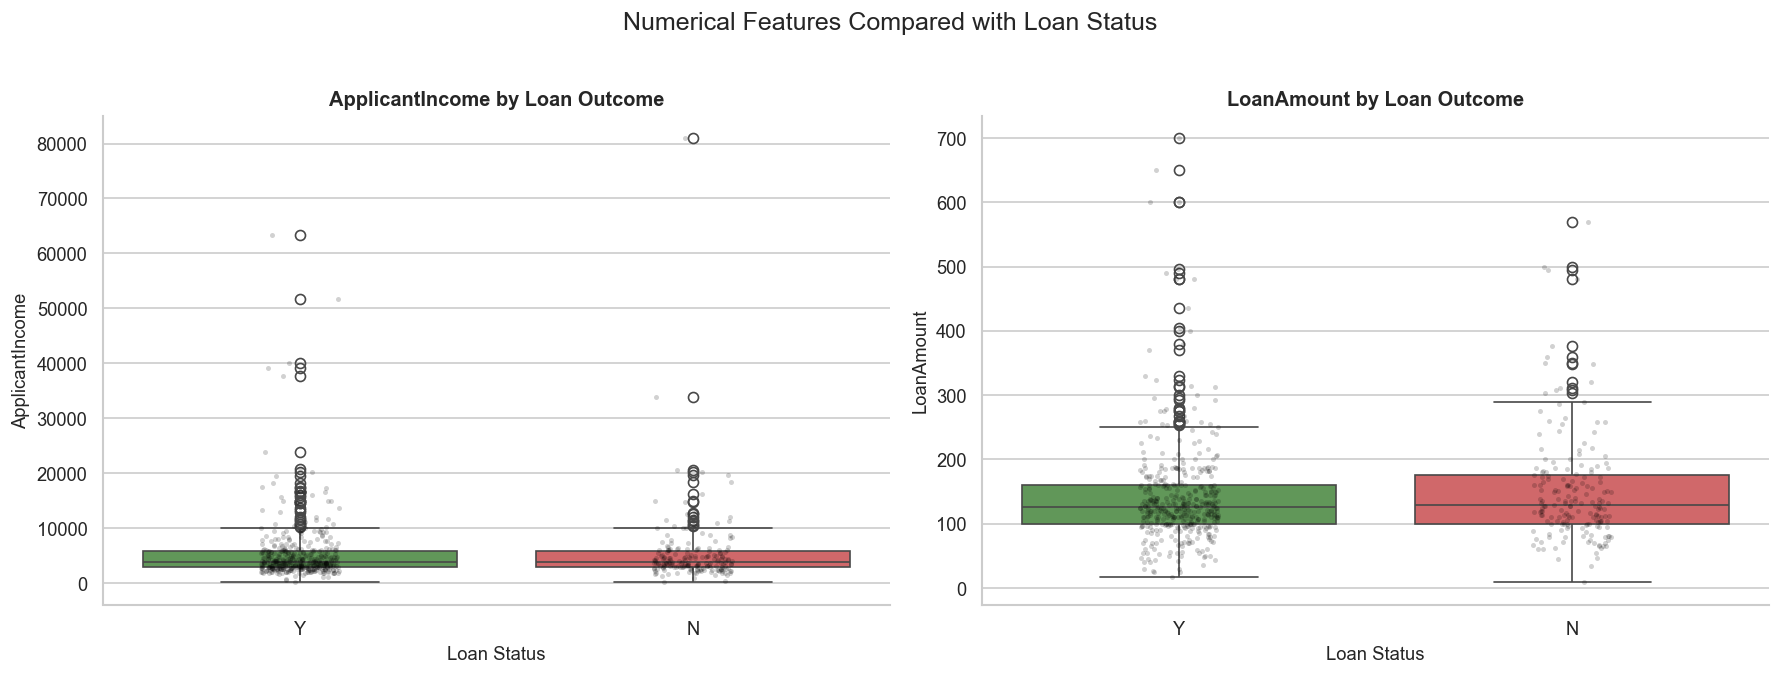

In [8]:
numeric_target_features = ["ApplicantIncome", "LoanAmount"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, feature in zip(axes, numeric_target_features):
    sns.boxplot(data=data, x="Loan_Status", y=feature, order=target_order,
                ax=ax, palette={"Y": "#59a14f", "N": "#e15759"})
    sns.stripplot(data=data, x="Loan_Status", y=feature, order=target_order,
                  ax=ax, color="black", alpha=0.18, size=3)
    ax.set_title(f"{feature} by Loan Outcome")
    ax.set_xlabel("Loan Status")
    ax.set_ylabel(feature)
fig.suptitle("Numerical Features Compared with Loan Status", y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

The income and loan amount boxplots compare central tendency and spread across outcomes. Overlap between groups indicates that these variables alone cannot deterministically decide approval; their predictive value is likely strongest when combined with credit history and applicant context.

## 7. Correlation Analysis

Pearson correlation is calculated for numerical variables and a temporary numeric representation of the binary target. This is an exploratory summary; it does not replace model-based feature evaluation and does not encode categorical variables for the production pipeline.

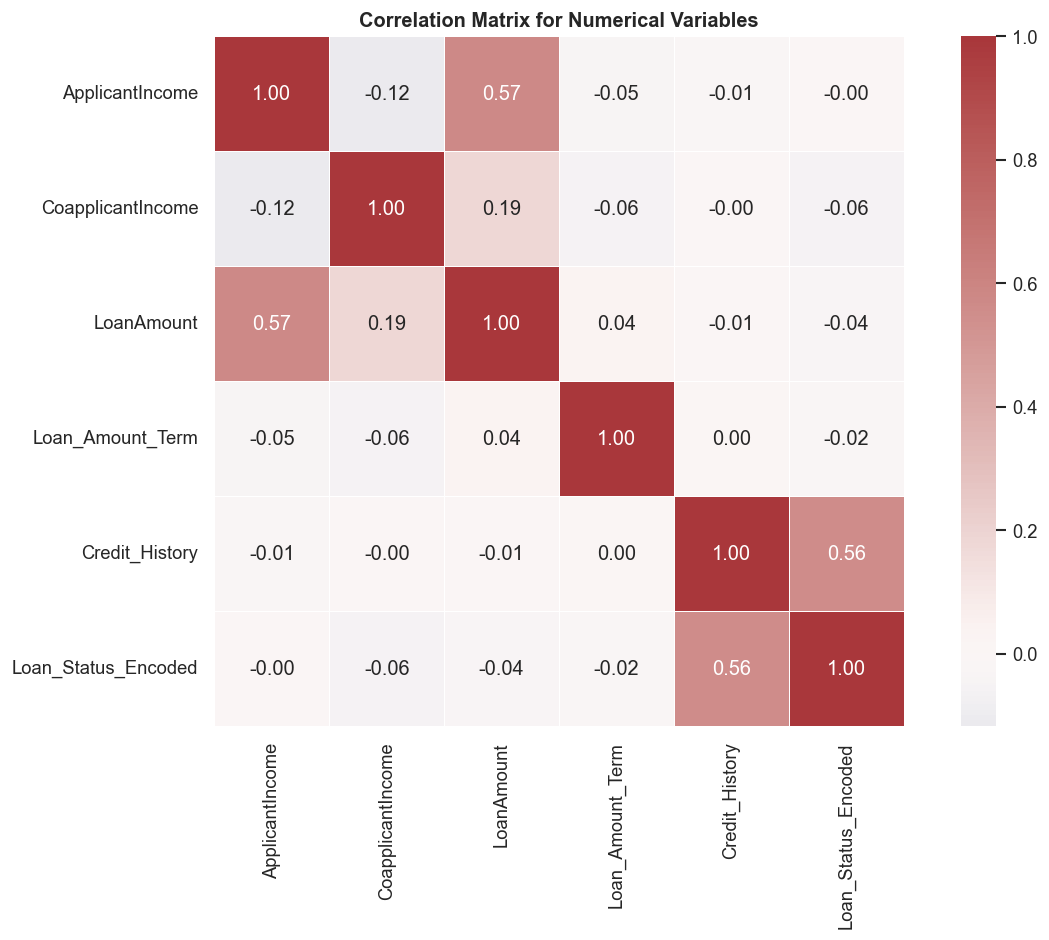

,correlation_with_approval
Loan_Status_Encoded,1.000000
Credit_History,0.561678
ApplicantIncome,-0.004710
Loan_Amount_Term,-0.021268
LoanAmount,-0.037318
CoapplicantIncome,-0.059187


In [9]:
correlation_data = data.copy()
correlation_data["Loan_Status_Encoded"] = correlation_data["Loan_Status"].map({"N": 0, "Y": 1})
correlation_matrix = correlation_data.select_dtypes(include=np.number).corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="vlag", center=0,
            linewidths=0.5, square=True, ax=ax)
ax.set_title("Correlation Matrix for Numerical Variables")
plt.tight_layout()
plt.show()

display(correlation_matrix["Loan_Status_Encoded"].sort_values(ascending=False).to_frame("correlation_with_approval"))

Correlation values describe linear association only. A weak correlation does not prove a feature is useless: categorical variables, nonlinear effects, interactions, and missingness patterns may still help tree-based or ensemble models. The heatmap is also useful for spotting redundancy among numerical inputs and checking whether scaling is needed for linear models.

## 8. Outlier Analysis

Boxplots help identify extreme numerical observations. Outliers are not automatically errors and should not be removed without domain evidence, especially in financial data where high-income applicants and large loans may be valid.

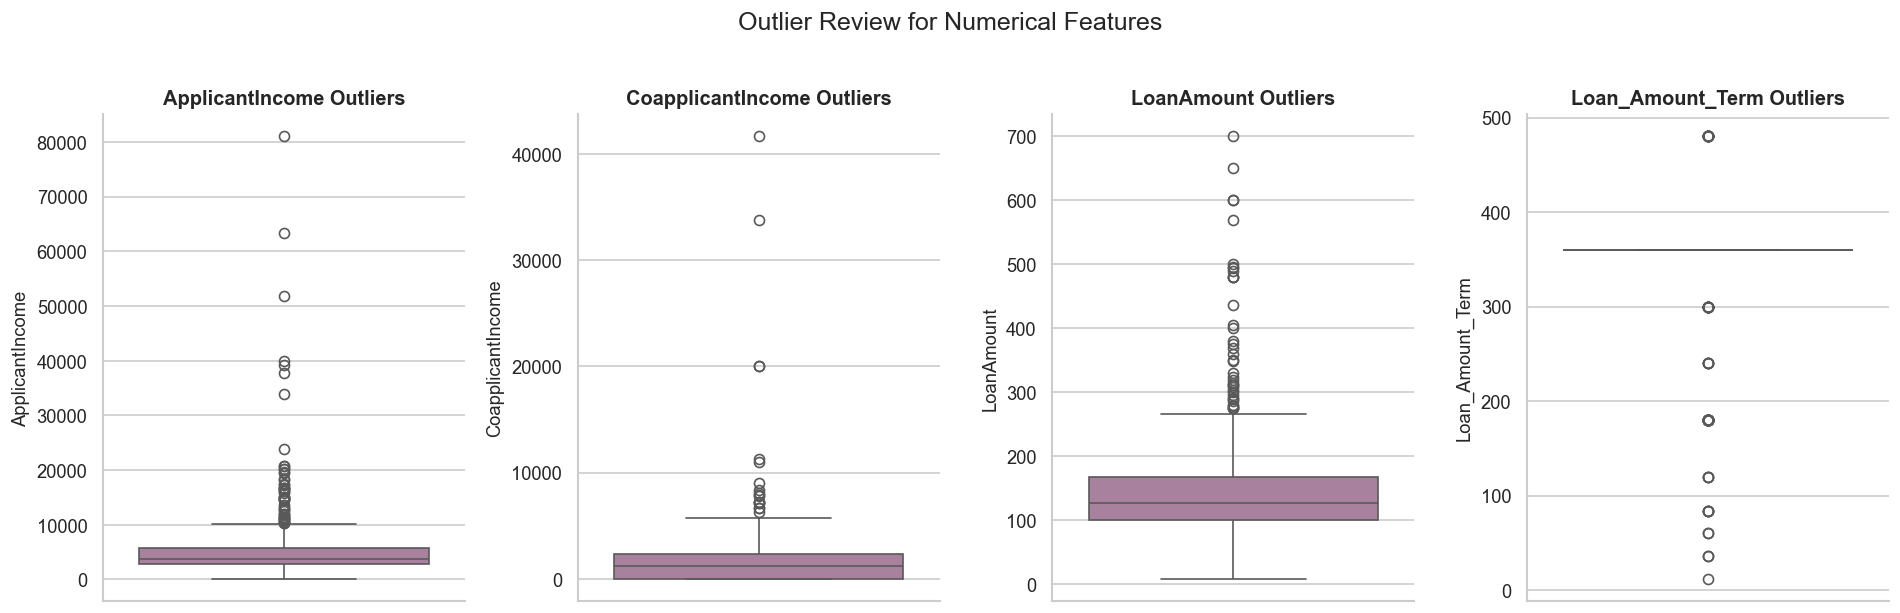

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, feature in zip(axes, numerical_features):
    sns.boxplot(data=data, y=feature, ax=ax, color="#af7aa1")
    ax.set_title(f"{feature} Outliers")
    ax.set_ylabel(feature)
fig.suptitle("Outlier Review for Numerical Features", y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

Income and loan amount commonly contain right-tail observations. The project keeps valid observations and uses model pipelines that can tolerate mixed feature behavior. Scaling numerical values helps Logistic Regression optimize consistently, while Decision Tree, Random Forest, and XGBoost can capture nonlinear thresholds without requiring the same scale assumptions.

## 9. Observations

### Most influential features
The selected model for this dataset is Logistic Regression. Its learned coefficients and controlled prediction checks indicate that `Credit_History` is the dominant factor. A good credit history strongly increases approval probability, while a poor credit history can lead to rejection even when income is very high. This is a historical pattern in the Kaggle data, not a universal lending rule.

Other positive associations in the fitted model include `Married = Yes`, `Property_Area = Semiurban`, and some dependent categories such as `Dependents = 2`. `Education = Graduate` is associated with better outcomes than `Not Graduate`. These relationships describe the training data and should not be interpreted as causal effects.

### Features with weaker or negative standalone relationships
Applicant income has a positive but comparatively weak learned effect, while loan amount has a slightly negative effect. Therefore, an income-to-loan ratio that appears financially strong does not automatically override the model's credit-history signal. `Self_Employed = Yes` has a slightly negative association in this historical dataset; this should not be interpreted as evidence that self-employed applicants are inherently higher risk. Gender, some dependent categories, and property-area categories show overlapping approval outcomes and are weaker standalone signals than credit history.

### Missing value observations
Missingness is present in several applicant fields, including credit history, loan amount, loan term, dependents, and self-employment. Dropping every incomplete row would reduce the already modest sample size and could introduce selection bias, so principled imputation is required.

### Class imbalance observations
Approved applications are the majority class. Evaluation must include metrics beyond accuracy to reveal whether the model handles both outcomes adequately.

### Feature engineering gap
The current feature set contains raw income and loan amount but does not explicitly calculate total income, income-to-loan ratio, or repayment burden. Adding these domain features could make financially intuitive relationships more visible, but they must be evaluated through leakage-safe pipelines and validation.

### Why preprocessing is required
The dataset combines numeric and categorical variables, includes missing values, and contains variables with very different scales. A reproducible preprocessing pipeline is needed to apply the same transformations during training and inference.

## 10. Link to Modeling

The EDA motivates the project's modeling design:

- **Median imputation** is appropriate for numerical fields because it is robust to the right-skewed income and loan distributions.
- **Mode imputation** preserves the most common observed category for missing categorical values.
- **One-hot encoding** converts nominal categories into model-compatible indicator features without imposing a false numeric order. Binary categories can be represented efficiently.
- **Feature scaling** places numerical variables on comparable scales for Logistic Regression and makes optimization more stable.
- **Logistic Regression** provides an interpretable linear baseline for binary approval prediction.
- **Decision Tree** can capture nonlinear thresholds and interactions without requiring scaled numeric inputs.
- **Random Forest** reduces the variance of a single tree by aggregating many randomized trees.
- **XGBoost** provides a powerful gradient-boosted tree comparison for nonlinear relationships and feature interactions.

All production transformations belong inside the saved sklearn pipeline so that training and Streamlit inference use the same feature handling.